# Тема 1. Анализ данных с Pandas

## Занятие 1 (теория)

**Каждый месяц часть клиентов телеком-оператора уходит к конкурентам.** Отдел поддержки не может обзвонить всех — нужно понять, кто уйдёт, ещё до того, как это случится. Ответ спрятан в таблице с историей звонков и тарифов: сегодня учимся эту таблицу читать — а к концу занятия найдём первую закономерность, которая реально предсказывает отток.

**План занятия:** структуры `Series`/`DataFrame` → загрузка и первый осмотр данных → `value_counts` → сортировка → индексация (`loc`/`iloc`, булева индексация) → `apply`/`map` → `groupby` → сводные таблицы → колонки → пропуски → итоговый кейс.

**Практика** по этой теме — в отдельном ноутбуке `lesson01_pandas_practice.ipynb` (датасет Titanic).
**Дополнительные темы** (NumPy, объединение таблиц, работа с датами) — в `lesson01_pandas_advanced.ipynb`, на занятии не разбираем.

**Обозначения в коде:** ячейки с `# ...` — их пишет преподаватель вживую на занятии (подсказка внутри, кода нет — специально, не выполнялись); ячейки с готовым кодом ниже — либо демонстрируют сложный/важный синтаксис целиком (и выполнены заранее), либо содержат `____` — тогда допишите пропуск сами.

---
## 1. Series и DataFrame

В Pandas есть две основные структуры данных:

- **`Series`** — одномерный массив значений с индексом (подписями к каждому элементу). Можно думать про него как про один столбец таблицы или как про `dict`, но с гарантированным порядком и удобными операциями.
- **`DataFrame`** — двумерная таблица: набор `Series`, у которых общий индекс (строки), и каждая колонка — это `Series` своего типа. Строки — это объекты (наблюдения), столбцы — это признаки.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 2)
%config InlineBackend.figure_format = 'svg'

**Задание преподавателю на занятии:** пока настоящих данных нет под рукой, потренируемся на игрушечном фрагменте — как будто у нас только 4 клиента.
1. Создайте `Series` из списка минут разговора `[280, 150, 90, 310]` с индексом-номерами клиентов `["C1", "C2", "C3", "C4"]`, сохраните в `minutes`, выведите.
2. Отфильтруйте `minutes`, оставив только клиентов, говоривших больше 200 минут (`minutes > 200` даёт булеву маску, ей же можно сразу индексировать) — этот же приём через пару минут применим к 3333 настоящим клиентам.
3. Заверните это в `DataFrame`: колонки `client_id` (список ID), `minutes` (те же числа), `many_calls` (True/False на ваш выбор). Сохраните в `df_toy`, выведите.

In [ ]:
# minutes = pd.Series(...)
# df_toy = pd.DataFrame({...})


Теперь перейдём к работе с настоящими данными.

---
## 2. Знакомство с датасетом

Будем работать с датасетом телеком-оператора: по каждому клиенту известны его тарифные опции и статистика звонков, а также признак `Churn` — ушёл ли клиент от оператора (*отток*, churn). Это реальная задача бизнеса: предсказать отток заранее и попытаться удержать клиента.

Загрузим данные (`read_csv`) и посмотрим на первые строки (`head`):

In [2]:
df = pd.read_csv("../data/telecom_churn.csv")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


**Задание преподавателю на занятии:**
1. `.shape` и `.columns` — размерность датасета и названия колонок.
2. `.info()` — типы всех колонок и есть ли пропуски (сравнивает число непустых значений с числом строк).

In [ ]:
# df.shape / df.columns
# df.info()


Признак `Churn` имеет тип `bool`. Для дальнейших вычислений (сравнений по числовым порогам, красивых таблиц с 0/1) удобнее привести его к `int64`:

In [3]:
df["Churn"] = df["Churn"].astype("int64")

`.describe()` — статистика по числовым колонкам (count, mean, std, min, квартили, max). Чтобы посмотреть на категориальные и булевы колонки — нужно явно указать `include`. Допишите пропуск (в pandas 3.x строковые колонки имеют тип `str`; в версиях до 3.0 — `object`, тогда используйте его вместо `str`):

In [ ]:
df.describe(include=[____, "bool"])

---
## 3. `value_counts()`

Для категориальных и булевых признаков полезно посмотреть на распределение значений — сколько раз встречается каждое, и с параметром `normalize=True` — какую долю составляет.

**Прежде чем считать — угадайте:** как думаете, какая доля клиентов из 3333 ушла — 5%, 15% или 30%? Проверим.

**Задание преподавателю на занятии:**
1. `df['Churn'].value_counts()` — абсолютные числа.
2. `df['Churn'].value_counts(normalize=True)` — доли.

In [ ]:
# df['Churn'].value_counts()
# df['Churn'].value_counts(normalize=True)


Так как `Churn` уже 0/1, тот же процент можно получить и одной строкой — `.mean()` по бинарному признаку сразу даёт долю единиц:

In [4]:
round(float(df["Churn"].mean() * 100), 1)

14.5

14.5% клиентов ушли — довольно высокий отток для телеком-бизнеса. Запомним эту цифру, она пригодится в финальном кейсе. У `Series` и `DataFrame` есть и `.plot()` — быстрый способ взглянуть на распределение глазами, не только числами (на следующем занятии будем строить графики подробно):

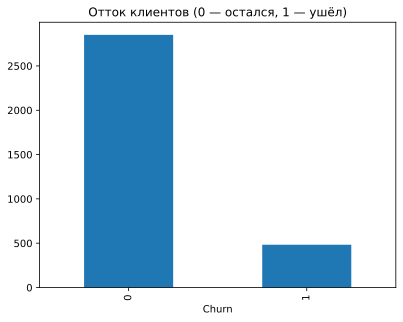

In [5]:
df["Churn"].value_counts().plot(kind="bar", title="Отток клиентов (0 — остался, 1 — ушёл)");

---
## 4. Сортировка: `sort_values()`

`DataFrame` можно отсортировать по значению одной или нескольких колонок (`ascending=False` — по убыванию).

**Задание преподавателю на занятии:**
1. Отсортируйте клиентов по убыванию `Total day charge` (плата за дневные звонки), выведите первые 5.
2. Отсортируйте сразу по двум колонкам: сначала по `Churn`, потом по `Total day charge` (по убыванию), с разным направлением сортировки для каждой (`ascending=[True, False]`).

In [ ]:
# df.sort_values(by=..., ascending=...).head()


---
## 5. Индексация и извлечение данных

Разные способы получить нужный кусок таблицы:

- **Одна колонка**: `df['col']` (или `df.col`) → возвращает `Series`
- **Несколько колонок**: `df[['col1', 'col2']]` → возвращает `DataFrame`
- **`loc`** — по меткам (названиям индекса/колонок), **включает** правую границу среза
- **`iloc`** — по позициям (числам, как в обычном срезе Python), **не включает** правую границу

**Задание преподавателю на занятии:** выведите одну колонку `df['Total day minutes']`.

In [ ]:
# df['Total day minutes']


**Булева индексация** — способ отфильтровать строки по условию: `df[P(df['col'])]`, где `P` — логическое условие.

**Задание преподавателю на занятии:** сравните, сколько в среднем говорят днём (`Total day minutes`) клиенты, которые ушли (`Churn == 1`), и те, кто остался (`Churn == 0`).

Ожидаемо: у ушедших заметно больше — примерно 207 минут против 175.

In [ ]:
# df[df["Churn"] == 1]["Total day minutes"].mean()
# df[df["Churn"] == 0]["Total day minutes"].mean()


**Важно:** при нескольких условиях используем `&` (И), `|` (ИЛИ), `~` (НЕ) — **не** `and`/`or`/`not`, и **каждое условие обязательно в скобках**:

```python
# Правильно:
df[(df['Churn'] == 0) & (df['International plan'] == 'No')]

# Неправильно — упадёт с ошибкой приоритета операторов:
df[df['Churn'] == 0 & df['International plan'] == 'No']
```

Найдём максимальную длительность международных звонков среди лояльных клиентов (`Churn == 0`) без подключённого международного тарифа (`International plan == 'No'`). Допишите пропуск — второе условие:

In [ ]:
df[(df["Churn"] == 0) & (____)]["Total intl minutes"].max()

`loc` — по меткам, включая правую границу. `iloc` — по позициям, как обычный питоновский срез.

**Задание преподавателю на занятии:**
1. `df.loc[0:5, "State":"Area code"]` — сколько строк вернулось?
2. `df.iloc[0:5, 0:3]` — а тут сколько?

(Ответ: `loc` вернёт 6 строк — включая правую границу, `iloc` вернёт 5 — как обычный срез.)

In [ ]:
# df.loc[0:5, "State":"Area code"]
# df.iloc[0:5, 0:3]


---
## 6. Применение функций: `apply()` и `map()`

`apply()` применяет функцию к каждой колонке (по умолчанию) или к каждой строке (`axis=1`). Часто используется с `lambda`.

**Задание преподавателю на занятии:** отберите клиентов из штатов, название которых начинается на `'W'` — `df[df['State'].apply(lambda state: state[0] == 'W')]`.

In [ ]:
# df[df["State"].apply(lambda state: state[0] == "W")].head()


`map()` заменяет значения колонки по словарю `{старое: новое}`. Переведём `International plan` из текста `Yes`/`No` в булев тип — пригодится в финальном кейсе:

In [6]:
d = {"No": False, "Yes": True}
df["International plan"] = df["International plan"].map(d)
df["International plan"].head()

0    False
1    False
2    False
3     True
4     True
Name: International plan, dtype: bool

> **Чем `map` отличается от `replace`?** `replace` не трогает значения, которых нет в словаре, а `map` заменяет их на `NaN`. Если словарь покрывает не все значения колонки — используйте `replace`, а не `map`.

---
## 7. Группировка: `groupby()` + `agg()`

Общая схема (*split-apply-combine*):

```python
df.groupby(by=grouping_columns)[columns_to_show].function()
```

1. **Split** — делим строки на группы по значению `grouping_columns`
2. **Apply** — считаем что-то по каждой группе
3. **Combine** — собираем результат в одну таблицу

Сравним статистику по разговорам у ушедших и лояльных клиентов сразу несколькими агрегатами через `.agg()` — синтаксис с несколькими функциями сразу легко забыть, поэтому целиком:

In [7]:
columns_to_show = ["Total day minutes", "Total eve minutes", "Total night minutes"]

df.groupby(["Churn"])[columns_to_show].agg(["mean", "std", "min", "max"])

Total day minutes                    Total eve minutes               \
                   mean    std  min    max              mean    std   min   
Churn                                                                       
0                175.18  50.18  0.0  315.6            199.04  50.29   0.0   
1                206.91  69.00  0.0  350.8            212.41  51.73  70.9   

             Total night minutes                      
         max                mean    std   min    max  
Churn                                                 
0      361.8              200.13  51.11  23.2  395.0  
1      363.7              205.23  47.13  47.4  354.9

Видно, что ушедшие клиенты в среднем говорят днём заметно дольше (206 минут против 175) — возможно, это связано с более высокими счетами.

---
## 8. Сводные таблицы: `crosstab()` и `pivot_table()`

**`crosstab`** — таблица сопряжённости: сколько наблюдений приходится на каждую комбинацию значений двух категориальных признаков. Разберём на первом примере целиком, дальше будет только `pivot_table` — по аналогии:

In [8]:
pd.crosstab(df["Churn"], df["International plan"], margins=True)

International plan,False,True,All
Churn,,,
0,2664,186,2850
1,346,137,483
All,3010,323,3333


Видно, что среди клиентов с международным тарифом отток заметно выше (137 из 323 ≈ 42%), чем без него (186 из 3010 ≈ 6%).

**`pivot_table`** — обобщение `crosstab`: можно агрегировать любую функцию по числовой колонке (`values`), группируя по одной или нескольким (`index`/`columns`). Посчитаем средние `Total day/eve/night calls` по каждому `Area code`. Допишите функцию агрегации (по умолчанию она и так `"mean"`, но укажем явно):

In [ ]:
df.pivot_table(
    values=["Total day calls", "Total eve calls", "Total night calls"],
    index=["Area code"],
    aggfunc=____,
)

---
## 9. Добавление и удаление колонок

Новую колонку можно посчитать из существующих и сразу присвоить.

**Задание преподавателю на занятии:**
1. Создайте колонку `Total calls` — сумма `Total day calls`, `Total eve calls`, `Total night calls`, `Total intl calls`. Выведите `df.head()`, чтобы убедиться, что колонка появилась.
2. Удалите её обратно — `df.drop(columns=[...], inplace=True)` (или `axis=1`).

In [ ]:
# df['Total calls'] = ...
# df.drop(...)


---
## 10. Пропуски в данных

В нашем датасете пропусков нет (видели в `.info()`), но на практике они почти всегда есть. Внесём немного искусственно в копию датасета и сразу же обработаем: `.isna()` — где пропуск, `.fillna(value)` — заполнить, `.dropna()` — выбросить. Код внесения пропусков непоказателен сам по себе — приведём целиком:

In [9]:
rng = np.random.default_rng(42)
df_missing = df.copy()

idx_num = rng.choice(df_missing.index, size=150, replace=False)
df_missing.loc[idx_num, "Total day minutes"] = np.nan

idx_cat = rng.choice(df_missing.index, size=80, replace=False)
df_missing.loc[idx_cat, "Voice mail plan"] = np.nan

df_missing.isna().sum()[df_missing.isna().sum() > 0]

Voice mail plan       80
Total day minutes    150
dtype: int64

In [10]:
median_minutes = df_missing["Total day minutes"].median()
df_missing["Total day minutes"] = df_missing["Total day minutes"].fillna(median_minutes)

df_missing = df_missing.dropna(subset=["Voice mail plan"])

df_missing.isna().sum().sum()

np.int64(0)

Числовой признак заполнили медианой (устойчива к выбросам), а строки с пропуском в категориальном признаке — просто выбросили, раз восстановить категорию нечем.

---
## 11. Итоговый мини-кейс: от EDA к первому правилу

Давайте попробуем предсказать отток «руками», без машинного обучения — этот же приём мы позже будем повторять с деревьями решений.

**Задание преподавателю на занятии:** постройте `pd.crosstab(df['Churn'], df['Customer service calls'], margins=True)` — как отток связан с числом обращений в поддержку? (Похоже, что начиная примерно с 4 обращений отток резко растёт.)

In [ ]:
# pd.crosstab(df["Churn"], df["Customer service calls"], margins=True)


Добавим бинарный признак «много обращений» и посмотрим на связь с оттоком одновременно с международным тарифом — здесь код важен для дальнейшего, приводим целиком:

In [11]:
df["Many_service_calls"] = (df["Customer service calls"] > 3).astype("int64")
df["Risky_combo"] = df["Many_service_calls"].astype(bool) & df["International plan"]

pd.crosstab(df["Risky_combo"], df["Churn"])

Churn,0,1
Risky_combo,,
False,2841,464
True,9,19


Сформулируем простое правило:

> Если у клиента подключён международный тариф **и** он обращался в поддержку больше 3 раз — предсказываем `Churn = 1`, иначе `Churn = 0`.

**Прежде чем считать — угадайте:** побьёт ли это правило точность в 85.5% (доля клиентов, которые и так остаются)? Посчитаем:

In [12]:
rule_predicts_churn = (df["Many_service_calls"] == 1) & df["International plan"]
accuracy = (rule_predicts_churn.astype(int) == df["Churn"]).mean()
round(float(accuracy * 100), 1)

85.8

Получилось **85.8%** — чуть лучше, чем наивное «все клиенты лояльны» (85.5%, это доля `Churn == 0`). Немного, но уже что-то, и мы получили это простым разведочным анализом — без единой модели МО.

Это будет нашей отправной точкой (*baseline*): любая обученная модель, которая не превосходит такое простое правило, скорее всего не стоит своей сложности. На следующих занятиях мы разберём, как алгоритм дерева решений находит подобные правила автоматически, по всем признакам сразу, а не только по двум выбранным вручную.

---
## Итог занятия

Сегодня разобрали:

- `Series`, `DataFrame` — базовые структуры
- `read_csv`, `head`, `info`, `describe`, `astype`
- `value_counts`
- `sort_values`
- `loc`/`iloc`, булева индексация (`&`, `|`, `~`, обязательные скобки)
- `apply`, `map`
- `groupby` + `agg`
- `crosstab`, `pivot_table`
- добавление/удаление колонок
- `isna`, `fillna`, `dropna`

**Дальше:**
- Практика по этой теме — `lesson01_pandas_practice.ipynb` (Titanic)
- Доп. материалы (NumPy, объединение таблиц, работа с датами) — `lesson01_pandas_advanced.ipynb`
- Следующее занятие — визуализация данных (matplotlib/seaborn)